# A Network-Defense Simulator — How Mitigations Restore Service Under a Flood

**This is a simulation, not a tool.** It generates no network traffic and contains no attack code —
it is a discrete-time *queueing model* used to study, defensively, how a denial-of-service flood
degrades a server and how standard mitigations claw the service back. The kind of thing a security or
networking course uses to reason about capacity and defense.

The setup: legitimate users and (during an attack window) a synthetic botnet flood both arrive at a
**finite-capacity server**; we measure the **legitimate-user success rate** under different defense
policies — none, per-source **rate limiting**, and anomaly-based **blocklisting**. Engine:
`network_defense_sim.py`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import network_defense_sim as nd

steps = nd.generate_traffic(T=200, n_legit=200, legit_rate=0.3,
                            attack_window=(80, 150), n_bots=60, bot_rate=40.0, seed=0)
print(f"{len(steps)} time steps; attack window 80-150")

200 time steps; attack window 80-150


## §1 The traffic — legitimate baseline plus an attack surge

Legitimate requests trickle in at a steady Poisson rate; during the attack window a botnet floods the
server far beyond its capacity (the dashed line). That asymmetry — a few sources generating enormous
traffic — is exactly what the defenses exploit.

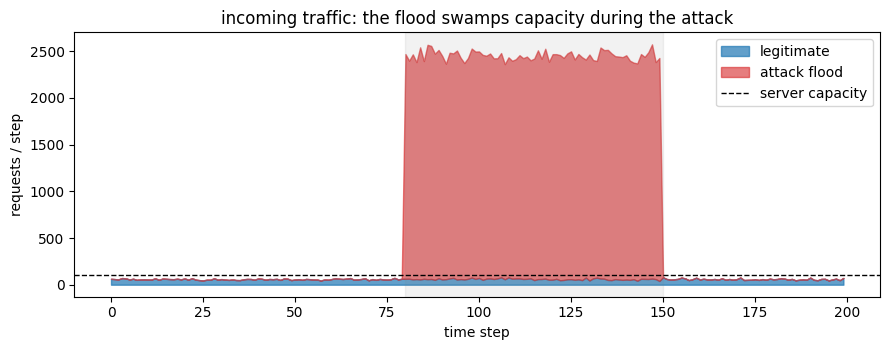

In [2]:
legit_per_step = np.array([st["legit"].sum() for st in steps])
attack_per_step = np.array([(~st["legit"]).sum() for st in steps])
capacity = 100

plt.figure(figsize=(9, 3.6))
plt.fill_between(range(len(steps)), 0, legit_per_step, color="C0", alpha=0.7, label="legitimate")
plt.fill_between(range(len(steps)), legit_per_step, legit_per_step + attack_per_step,
                color="C3", alpha=0.6, label="attack flood")
plt.axhline(capacity, color="k", ls="--", lw=1, label="server capacity")
plt.axvspan(80, 150, color="gray", alpha=0.1)
plt.xlabel("time step"); plt.ylabel("requests / step"); plt.legend(loc="upper right")
plt.title("incoming traffic: the flood swamps capacity during the attack")
plt.tight_layout(); plt.show()

## §2 With no defense, legitimate users are starved

The server serves up to its capacity from whatever arrives; during the flood, legitimate requests are
a tiny fraction of the queue, so almost none get through. The success rate collapses.

overall legitimate success: 65.9%


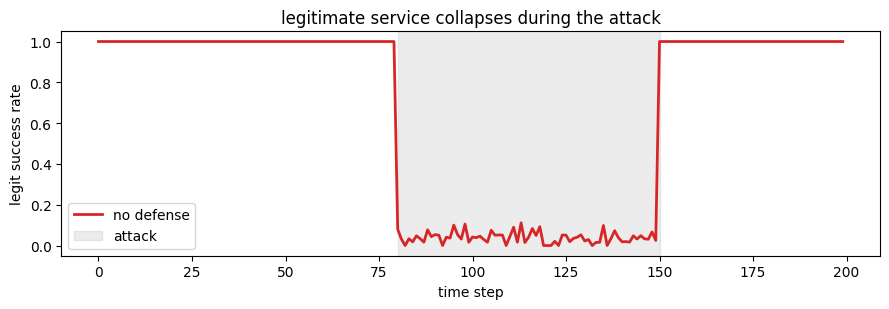

In [3]:
none = nd.simulate(steps, capacity=capacity, policy="none")
print(f"overall legitimate success: {none['legit_success_rate']*100:.1f}%")

def served_rate(r):
    return r["legit_served"] / np.maximum(r["legit_sent"], 1)

plt.figure(figsize=(9, 3.2))
plt.plot(served_rate(none), "C3", lw=2, label="no defense")
plt.axvspan(80, 150, color="gray", alpha=0.15, label="attack")
plt.ylim(-0.05, 1.05); plt.xlabel("time step"); plt.ylabel("legit success rate")
plt.title("legitimate service collapses during the attack"); plt.legend()
plt.tight_layout(); plt.show()

## §3 Mitigations restore service

- **Per-source rate limiting** (token bucket): cap how many requests any one source may make per step.
  Helps, but a large botnet still adds up.
- **Anomaly blocklisting**: track per-source rates, flag the ones far above normal, and drop them — an
  outlier detector pointed at source addresses. This is the same rare-event/anomaly idea as the
  unsupervised-learning notebook, now defending a server.

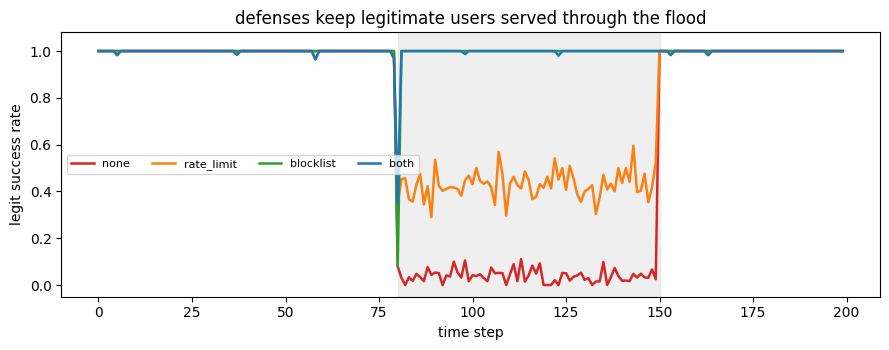

legitimate success DURING the attack window:
  none      :   4.0%   (final blocklist size 0)
  rate_limit:  42.6%   (final blocklist size 0)
  blocklist :  98.6%   (final blocklist size 60)
  both      :  99.0%   (final blocklist size 60)


In [4]:
policies = {"none": "C3", "rate_limit": "C1", "blocklist": "C2", "both": "C0"}
results = {p: nd.simulate(steps, capacity=capacity, policy=p) for p in policies}

plt.figure(figsize=(9, 3.6))
for p, c in policies.items():
    plt.plot(served_rate(results[p]), c, lw=1.8, label=p)
plt.axvspan(80, 150, color="gray", alpha=0.12)
plt.ylim(-0.05, 1.08); plt.xlabel("time step"); plt.ylabel("legit success rate")
plt.title("defenses keep legitimate users served through the flood"); plt.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

aw = slice(80, 150)
print("legitimate success DURING the attack window:")
for p in policies:
    s = results[p]["legit_served"][aw].sum() / max(results[p]["legit_sent"][aw].sum(), 1)
    print(f"  {p:10}: {s*100:5.1f}%   (final blocklist size {results[p]['blocklist_size'][-1]})")

## §4 Defense efficacy at a glance

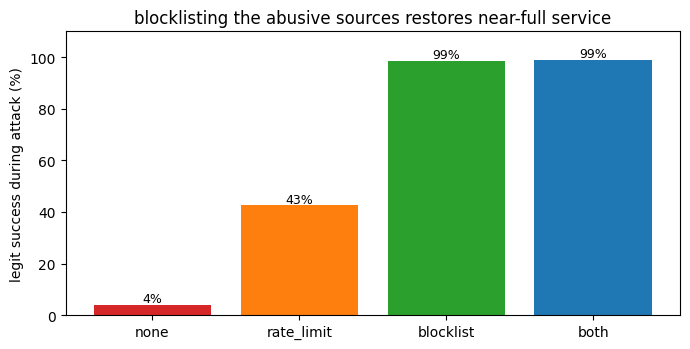

In [5]:
aw = slice(80, 150)
labels = list(policies)
vals = [results[p]["legit_served"][aw].sum() / max(results[p]["legit_sent"][aw].sum(), 1) * 100
        for p in labels]
plt.figure(figsize=(7, 3.6))
bars = plt.bar(labels, vals, color=[policies[p] for p in labels])
for b, v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v+1, f"{v:.0f}%", ha="center", fontsize=9)
plt.ylabel("legit success during attack (%)"); plt.ylim(0, 110)
plt.title("blocklisting the abusive sources restores near-full service")
plt.tight_layout(); plt.show()

## §5 What the simulator teaches (defensively)

- **Capacity alone loses.** A server that just serves whatever arrives is defenceless — the flood
  crowds out real users (§2). Defense has to act *before* the queue.
- **Identify the asymmetry.** DDoS works by concentrating traffic in few sources; the mitigations
  here detect exactly that — rate limiting caps any single source, blocklisting removes the worst
  offenders. The blocklist is **anomaly detection on source addresses**, the same outlier idea as
  `majority_imbalance_rotten_labels.ipynb` / `unsupervised_jalali_rogue.ipynb`, now in network defence.
- **Layer the defences.** Combining rate limiting and blocklisting is the most robust ("both"),
  because each covers the other's gaps (slow-and-distributed vs fast-and-concentrated attackers).
- **It is a model, use it as one.** Real deployments add upstream scrubbing, CDNs/anycast, SYN
  cookies, and CAPTCHAs; this simulator is for reasoning about the *dynamics* and sizing the
  mitigations, not for touching any real network.

Engine: `network_defense_sim.py` (traffic model, finite-capacity server, rate-limit + anomaly-
blocklist policies), benchmarked in `scripts/smoke_netdef.py`. Pure simulation -- no real traffic,
no attack tooling.